# 从零实现 Transformer —— 完整教学 Notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/songyaolun/transformer-from-scratch/blob/main/transformer_from_scratch.ipynb)

本 Notebook 包含完整的 5 篇系列文章代码，可逐个 Cell 运行。

> **在线阅读文章版**：[https://songyaolun.github.io/transformer-from-scratch/](https://songyaolun.github.io/transformer-from-scratch/)

## 目录
1. [第一篇：PyTorch 基础与神经网络模块](#part1)
2. [第二篇：数据处理与 Transformer 输入层](#part2)
3. [第三篇：多头注意力机制与核心组件](#part3)
4. [第四篇：Transformer 模型组装](#part4)
5. [第五篇：训练、推理与可视化](#part5)

---
<a id='part1'></a>
# 第一篇：PyTorch 基础与神经网络模块

对应文章：[01-pytorch-basics.md](https://songyaolun.github.io/transformer-from-scratch/01-pytorch-basics/)

In [1]:
# 在 Google Colab 中运行时，取消下面的注释来安装依赖
# !pip install torch numpy matplotlib seaborn -q

## 1.1 环境准备

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import math
import numpy as np

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"设备: {device}")

设备: cpu


## 1.2 张量创建

In [ ]:
# 从列表创建
x = torch.tensor([1, 2, 3])
print(x)
print(x.shape)

# 从二维列表创建
matrix = torch.tensor([[1, 2], [3, 4]])
print(matrix)
print(matrix.shape)

tensor([1, 2, 3])
torch.Size([3])
tensor([[1, 2],
        [3, 4]])
torch.Size([2, 2])


In [ ]:
# zeros, ones, randn
x = torch.zeros(2, 3)
print(f"zeros: {x.shape}")

x = torch.ones(3, 2)
print(f"ones: {x.shape}")

x = torch.randn(3, 4)
print(f"randn: {x.shape}")

zeros: torch.Size([2, 3])
ones: torch.Size([3, 2])
randn: torch.Size([3, 4])


## 1.3 张量属性与索引

In [ ]:
x = torch.randn(2, 4, 5)
print(f"shape: {x.shape}")
print(f"dim: {x.dim()}")
print(f"numel: {x.numel()}")
print(f"dtype: {x.dtype}")

shape: torch.Size([2, 4, 5])
dim: 3
numel: 40
dtype: torch.float32


In [ ]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(f"x[0, 1] = {x[0, 1]}")
print(f"x[0] = {x[0]}")
print(f"x[:, 1:] = {x[:, 1:]}")
print(f"x[:, :-1] = {x[:, :-1]}")

x[0, 1] = 2
x[0] = tensor([1, 2, 3])
x[:, 1:] = tensor([[2, 3],
        [5, 6]])
x[:, :-1] = tensor([[1, 2],
        [4, 5]])


## 1.4 形状操作

In [ ]:
# view: 变换形状
x = torch.randn(2, 3, 4)
print(f"原始: {x.shape}")

x_flat = x.view(2, -1)
print(f"view(2, -1): {x_flat.shape}")

x_high = x_flat.view(2, 2, -1, 2)
print(f"view(2, 2, -1, 2): {x_high.shape}")

原始: torch.Size([2, 3, 4])
view(2, -1): torch.Size([2, 12])
view(2, 2, -1, 2): torch.Size([2, 2, 3, 2])


In [ ]:
# 多头注意力中的 view 用法
B, T, C = 2, 3, 8
x = torch.randn(B, T, C)
n_heads = 2
head_dim = C // n_heads
x_heads = x.view(B, T, n_heads, head_dim)
print(f"拆分多头: {x_heads.shape}")  # (2, 3, 2, 4)

拆分多头: torch.Size([2, 3, 2, 4])


In [ ]:
# transpose 与 permute
x = torch.randn(2, 3, 4)
print(f"transpose(1,2): {x.transpose(1, 2).shape}")  # (2, 4, 3)

x = torch.randn(2, 3, 4, 5)
print(f"permute(0,3,1,2): {x.permute(0, 3, 1, 2).shape}")  # (2, 5, 3, 4)

transpose(1,2): torch.Size([2, 4, 3])
permute(0,3,1,2): torch.Size([2, 5, 3, 4])


In [ ]:
# 真实 Transformer 中的多头拆分
B, T, C = 2, 3, 512
n_head = 8
head_dim = C // n_head
x = torch.randn(B, T, C)
x = x.view(B, T, n_head, head_dim)
x = x.permute(0, 2, 1, 3)
print(f"多头拆分后: {x.shape}")  # (2, 8, 3, 64)

多头拆分后: torch.Size([2, 8, 3, 64])


In [ ]:
# unsqueeze / squeeze
x = torch.tensor([1, 2, 3])
print(f"原始: {x.shape}")
print(f"unsqueeze(0): {x.unsqueeze(0).shape}")
print(f"unsqueeze(1): {x.unsqueeze(1).shape}")

x = torch.randn(1, 3, 1, 4)
print(f"\nsqueeze前: {x.shape}")
print(f"squeeze后: {x.squeeze().shape}")

原始: torch.Size([3])
unsqueeze(0): torch.Size([1, 3])
unsqueeze(1): torch.Size([3, 1])

squeeze前: torch.Size([1, 3, 1, 4])
squeeze后: torch.Size([3, 4])


In [ ]:
# torch.cat 拼接
x1 = torch.tensor([[1, 2, 3], [4, 5, 6]])
x2 = torch.tensor([[7, 8, 9], [10, 11, 12]])
print(f"cat dim=0: {torch.cat([x1, x2], dim=0).shape}")  # (4, 3)
print(f"cat dim=1: {torch.cat([x2, x1], dim=1).shape}")  # (2, 6)

cat dim=0: torch.Size([4, 3])
cat dim=1: torch.Size([2, 6])


In [ ]:
# contiguous: 确保内存连续
x = torch.randn(2, 3, 4)
x = x.transpose(0, 1)
# x.view(2, 4, 3)  # 会报错！
x = x.contiguous()
x = x.view(2, 4, 3)  # 正常
print(f"contiguous 后 view: {x.shape}")

contiguous 后 view: torch.Size([2, 4, 3])


## 1.5 nn.Module 基础

In [ ]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 5)

    def forward(self, x):
        return self.linear(x)

model = MyModel()
print(type(model))
print(isinstance(model, MyModel))

<class '__main__.MyModel'>
True


In [ ]:
# 不调用 super().__init__() 会报错
class BrokenModel(nn.Module):
    def __init__(self):
        self.linear = nn.Linear(10, 5)

try:
    model = BrokenModel()
except AttributeError as e:
    print(f"报错了: {e}")

报错了: cannot assign module before Module.__init__() call


In [ ]:
# 调用链演示
class MyLayer(nn.Module):
    def __init__(self, in_features, out_features, name="MyLayer"):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.name = name
        print(f"MyLayer 初始化完成，weight shape: {self.weight.shape}")

    def forward(self, x):
        print(f"MyLayer {self.name} 的forward被调用，input shape: {x.shape}")
        return x @ self.weight.t()

class MyModel(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.layer1 = MyLayer(in_features, 40, "layer1")
        self.layer2 = MyLayer(40, 5, "layer2")

    def forward(self, x):
        print(f"MyModel 的forward被调用，input shape: {x.shape}")
        x = self.layer1(x)
        x = torch.relu(x)
        return self.layer2(x)

print("==== 创建模型 ====")
model = MyModel(10, 20)
print("\n==== 调用模型 ====")
x = torch.randn(2, 10)
output = model(x)
print(f"\n最终输出 shape: {output.shape}")

==== 创建模型 ====
MyLayer 初始化完成，weight shape: torch.Size([40, 10])
MyLayer 初始化完成，weight shape: torch.Size([5, 40])

==== 调用模型 ====
MyModel 的forward被调用，input shape: torch.Size([2, 10])
MyLayer layer1 的forward被调用，input shape: torch.Size([2, 10])
MyLayer layer2 的forward被调用，input shape: torch.Size([2, 40])

最终输出 shape: torch.Size([2, 5])


## 1.6 常用层

In [ ]:
# nn.Linear
linear = nn.Linear(10, 5)
x = torch.randn(2, 10)
print(f"Linear output: {linear(x).shape}")

# nn.Embedding
embedding = nn.Embedding(num_embeddings=1000, embedding_dim=64)
indices = torch.tensor([1, 5, 3, 10])
print(f"Embedding output: {embedding(indices).shape}")

batch_indices = torch.tensor([[1, 4, 6], [10, 5, 19]])
print(f"Embedding batch output: {embedding(batch_indices).shape}")

Linear output: torch.Size([2, 5])
Embedding output: torch.Size([4, 64])
Embedding batch output: torch.Size([2, 3, 64])


In [ ]:
# LayerNorm
torch.manual_seed(42)
dim = 5
layer_norm = nn.LayerNorm(dim)
x = torch.randn(2, 10, dim)
print(f"归一化前: {x[0][0]}")
print(f"归一化后: {layer_norm(x[0][0])}")

# Dropout
drop_out = nn.Dropout(0.5)
print(f"\nDropout前: {x[0][0]}")
print(f"Dropout后: {drop_out(x[0][0])}")
print("注意：非零值变成了原来的 2 倍（1/(1-0.5)），保证期望不变")

归一化前: tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784])
归一化后: tensor([ 0.9560,  0.6445,  0.2289, -1.9008,  0.0715],
       grad_fn=<NativeLayerNormBackward0>)

Dropout前: tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784])
Dropout后: tensor([0.0000, 2.9746, 1.8014, -0.0000, 1.3568])
注意：非零值变成了原来的 2 倍（1/(1-0.5)），保证期望不变


In [ ]:
# 激活函数
x = torch.tensor([-1.0, -0.5, 1.0, 2.0])
print(f"ReLU: {F.relu(x)}")

x = torch.tensor([1.0, 2.0, 3.0])
print(f"Softmax: {F.softmax(x, dim=-1)}")
print(f"Softmax sum: {F.softmax(x, dim=-1).sum()}")

ReLU: tensor([0., 0., 1., 2.])
Softmax: tensor([0.0900, 0.2447, 0.6652])
Softmax sum: 1.0


## 1.7 训练相关

In [ ]:
# 设备管理
x_cpu = torch.ones((3, 3))
print(f"x_cpu: device={x_cpu.device}, id={id(x_cpu)}")

x_gpu = x_cpu.to(device)
print(f"x_gpu: device={x_gpu.device}, id={id(x_gpu)}")
print("注意 id 不同，说明 tensor.to() 不是原地操作")

net = nn.Sequential(nn.Linear(3, 3))
print(f"\nmodel id: {id(net)}")
net.to(device)
print(f"model id: {id(net)}")
print("id 相同，model.to() 是原地操作")

x_cpu: device=cpu, id=4688087792
x_gpu: device=mps:0, id=4688088592
注意 id 不同，说明 tensor.to() 不是原地操作

model id: 4627529216
model id: 4627529216
id 相同，model.to() 是原地操作


In [ ]:
# 损失函数
criterion = nn.CrossEntropyLoss()
output = torch.tensor([[1.5, 0.2, -0.5], [0.1, 2.0, 0.3]])
target = torch.tensor([0, 2])
print(f"CrossEntropy Loss: {criterion(output, target)}")

criterion = nn.MSELoss()
output = torch.tensor([[200.0], [400.0]])
target = torch.tensor([[220.0], [380.0]])
print(f"MSE Loss: {criterion(output, target)}")

CrossEntropy Loss: 1.164473295211792
MSE Loss: 400.0


In [ ]:
# 梯度计算
x = torch.tensor([2.0], requires_grad=True)
y = x ** 2
y.backward()
print(f"x.grad = {x.grad}")  # 4.0，对 y=x² 求导，x=2 时梯度为 4

# detach
x = torch.tensor([2.0], requires_grad=True)
y = x ** 2
z = y.detach()
print(f"z = {z}, requires_grad = {z.requires_grad}")

x.grad = tensor([4.])
z = tensor([4.]), requires_grad = False


In [ ]:
# 矩阵乘法
a = torch.tensor([[1, 2, 3], [4, 5, 6]])
b = torch.tensor([[7, 8], [9, 10], [11, 12]])
print(f"a @ b = {a @ b}")

# 掩码操作
x = torch.randn(2, 3)
mask = torch.tensor([[True, False, True], [False, True, False]])
result = x.masked_fill(mask, -1e9)
print(f"\nmasked_fill 结果:\n{result}")

# 三角掩码
x = torch.ones(4, 4)
print(f"\n上三角:\n{torch.triu(x)}")
print(f"下三角:\n{torch.tril(x)}")

a @ b = tensor([[ 58,  64],
        [139, 154]])

masked_fill 结果:
tensor([[-1.0000e+09,  1.0060e+00, -1.0000e+09],
        [-1.6271e-01, -1.0000e+09,  5.7073e-01]])

上三角:
tensor([[1., 1., 1., 1.],
        [0., 1., 1., 1.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.]])
下三角:
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])


In [ ]:
# 一个完整的神经网络
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 20)
        self.fc2 = nn.Linear(20, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = SimpleNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

x = torch.randn(32, 10)
y = torch.randint(0, 2, (32,))

model.train()
optimizer.zero_grad()
output = model(x)
loss = criterion(output, y)
loss.backward()
optimizer.step()
print(f"损失值: {loss.item():.4f}")

损失值: 0.7518


---
<a id='part2'></a>
# 第二篇：数据处理与 Transformer 输入层

对应文章：[02-data-and-input-layer.md](https://songyaolun.github.io/transformer-from-scratch/02-data-and-input-layer/)

## 2.1 构建迷你翻译数据集和词表

In [ ]:
# 构建原始数据集
raw_data = [
    ("I love deep learning", "我爱深度学习"),
    ("Transformer is all you need", "你需要的就是变形金刚"),
    ("Attention mechanism is great", "注意力机制很棒"),
    ("hello world", "你好世界"),
    ("PyTorch is easy to learn", "PyTorch很容易学")
]

# 构建词表
src_vocab = {'<pad>': 0, '<sos>': 1, '<eos>': 2}
tgt_vocab = {'<pad>': 0, '<sos>': 1, '<eos>': 2}

for src, tar in raw_data:
    for word in src.split():
        if word not in src_vocab:
            src_vocab[word] = len(src_vocab)
    for word in tar:
        if word not in tgt_vocab:
            tgt_vocab[word] = len(tgt_vocab)

idx2src = {v: k for k, v in src_vocab.items()}
idx2tar = {v: k for k, v in tgt_vocab.items()}

print(f"源语言词表大小: {len(src_vocab)}")
print(f"目标语言词表大小: {len(tgt_vocab)}")
print(f"源语言词表: {src_vocab}")

源语言词表大小: 21
目标语言词表大小: 38
源语言词表: {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'I': 3, 'love': 4, 'deep': 5, 'learning': 6, 'Transformer': 7, 'is': 8, 'all': 9, 'you': 10, 'need': 11, 'Attention': 12, 'mechanism': 13, 'great': 14, 'hello': 15, 'world': 16, 'PyTorch': 17, 'easy': 18, 'to': 19, 'learn': 20}


## 2.2 Dataset 与 DataLoader (Padding)

In [ ]:
class ToyTranslationDataset(data.Dataset):
    def __init__(self, data, src_vocab, tgt_vocab):
        self.data = data
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text, tgt_text = self.data[idx]
        src_indices = [self.src_vocab[word] for word in src_text.split()]
        tgt_indices = [self.tgt_vocab[word] for word in tgt_text]
        return torch.tensor(src_indices), torch.tensor(tgt_indices)

In [ ]:
def collate_fn(batch):
    """自定义 batch 处理：补前后标识 + 补 0"""
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(src_sample)
        tar_processed = torch.cat([
            torch.tensor([tgt_vocab['<sos>']]),
            tgt_sample,
            torch.tensor([tgt_vocab['<eos>']])
        ])
        tgt_batch.append(tar_processed)

    src_batch = nn.utils.rnn.pad_sequence(src_batch, padding_value=0, batch_first=True)
    tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, padding_value=0, batch_first=True)
    return src_batch, tgt_batch


dataset = ToyTranslationDataset(raw_data, src_vocab, tgt_vocab)
loader = data.DataLoader(dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

src_batch, tgt_batch = next(iter(loader))

print(f"Source Batch Shape: {src_batch.shape}")
print(f"Target Batch Shape: {tgt_batch.shape}")
print(f"\nSource:\n{src_batch}")
print(f"Target:\n{tgt_batch}")

Source Batch Shape: torch.Size([2, 5])
Target Batch Shape: torch.Size([2, 12])

Source:
tensor([[ 3,  4,  5,  6,  0],
        [ 7,  8,  9, 10, 11]])
Target:
tensor([[ 1,  3,  4,  5,  6,  7,  8,  2,  0,  0,  0,  0],
        [ 1,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,  2]])


## 2.3 词嵌入（Token Embedding）

In [ ]:
# Embedding 本质就是查表
emb_layer = nn.Embedding(num_embeddings=10, embedding_dim=4)
print(f"Embedding 权重矩阵形状: {emb_layer.weight.shape}")

input_ids = torch.tensor([3, 0, 7])
outputs = emb_layer(input_ids)
print(f"输出形状: {outputs.shape}")

# 验证查表
print(f"权重第3行: {emb_layer.weight.data[3]}")
print(f"输出第0个: {outputs[0]}")
print(f"相等: {torch.equal(emb_layer.weight.data[3], outputs.data[0])}")

Embedding 权重矩阵形状: torch.Size([10, 4])
输出形状: torch.Size([3, 4])
权重第3行: tensor([-0.4709,  0.6016, -0.2825,  0.7693])
输出第0个: tensor([-0.4709,  0.6016, -0.2825,  0.7693], grad_fn=<SelectBackward0>)
相等: True


In [ ]:
# 缩放因子 sqrt(d_model)
d_model = 512
emb_large = nn.Embedding(100, d_model)
sample = emb_large(torch.tensor([1]))
print(f"未缩放 - 均值: {sample.mean().item():.4f}, 标准差: {sample.std().item():.4f}")

sample_scaled = sample * math.sqrt(d_model)
print(f"缩放后 - 均值: {sample_scaled.mean().item():.4f}, 标准差: {sample_scaled.std().item():.4f}")
print(f"缩放因子 sqrt({d_model}) = {math.sqrt(d_model):.2f}")

未缩放 - 均值: -0.0304, 标准差: 1.0072
缩放后 - 均值: -0.6887, 标准差: 22.7903
缩放因子 sqrt(512) = 22.63


## 2.4 位置编码（Positional Encoding）

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x

print("PositionalEncoding 定义完成")

PositionalEncoding 定义完成


## 2.5 组合 Embedding + Positional Encoding

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super(TokenEmbedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)


class TransformerInputLayer(nn.Module):
    def __init__(self, vocab_size, emb_size, max_len=5000, dropout=0.1):
        super().__init__()
        self.token_emb = TokenEmbedding(vocab_size, emb_size)
        self.pos_emb = PositionalEncoding(emb_size, max_len)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = self.token_emb(x)
        out = self.pos_emb(out)
        return self.dropout(out)

# 测试
input_layer = TransformerInputLayer(len(src_vocab), 512)
test_input = torch.tensor([[1, 2, 3, 0, 0]])
test_output = input_layer(test_input)
print(f"输入层输出 shape: {test_output.shape}")  # (1, 5, 512)

输入层输出 shape: torch.Size([1, 5, 512])


---
<a id='part3'></a>
# 第三篇：多头注意力机制与核心组件

对应文章：[03-multi-head-attention.md](https://songyaolun.github.io/transformer-from-scratch/03-multi-head-attention/)

## 3.1 多头注意力机制

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"

        self.d_k = d_model // num_heads
        self.n_heads = num_heads
        self.d_model = d_model

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        Q = self.w_q(q).view(batch_size, -1, self.n_heads, self.d_k).permute(0, 2, 1, 3)
        K = self.w_k(k).view(batch_size, -1, self.n_heads, self.d_k).permute(0, 2, 1, 3)
        V = self.w_v(v).view(batch_size, -1, self.n_heads, self.d_k).permute(0, 2, 1, 3)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        context = torch.matmul(attn, V)
        context = context.permute(0, 2, 1, 3).contiguous().view(batch_size, -1, self.d_model)
        output = self.fc(context)
        return output, attn


# 测试
d_model = 512
num_heads = 8
mha = MultiHeadAttention(d_model, num_heads)
x = torch.randn(2, 10, 512)
out, attn_map = mha(x, x, x, mask=None)
print(f"Input:  {x.shape}")
print(f"Output: {out.shape}")
print(f"Attention Map: {attn_map.shape}")

Input:  torch.Size([2, 10, 512])
Output: torch.Size([2, 10, 512])
Attention Map: torch.Size([2, 8, 10, 10])


## 3.2 前馈神经网络（FFN）

In [ ]:
class FFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(FFN, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

print("FFN 定义完成")

FFN 定义完成


## 3.3 残差连接与层归一化

In [ ]:
# LayerNorm 演示
x = torch.tensor([[[1.0, 2.0, 3.0, 4.0],
                    [5.0, 6.0, 7.0, 8.0],
                    [9.0, 10., 11., 12.]],
                   [[0.1, 0.2, 0.3, 0.4],
                    [0.5, 0.6, 0.7, 0.8],
                    [0.9, 1.0, 1.1, 1.2]]])

layer_norm = nn.LayerNorm(4)
output = layer_norm(x)

print(f"归一化前: 均值={x[0,0,:].mean():.4f}, 标准差={x[0,0,:].std(unbiased=False):.4f}")
print(f"归一化后: 均值={output[0,0,:].mean():.4f}, 标准差={output[0,0,:].std(unbiased=False):.4f}")

归一化前: 均值=2.5000, 标准差=1.1180
归一化后: 均值=0.0000, 标准差=1.0000


## 3.4 组装 Encoder Layer

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output, _ = self.self_attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))
        return x

print("EncoderLayer 定义完成")

EncoderLayer 定义完成


## 3.5 组装 Decoder Layer

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.cross_attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output, _ = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))

        attn_output, attn_map = self.cross_attention(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))

        ffn_output = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_output))
        return x, attn_map

print("DecoderLayer 定义完成")

DecoderLayer 定义完成


In [ ]:
# 测试 Encoder Layer 和 Decoder Layer
d_model = 512
num_heads = 8
d_ff = 2048
batch_size = 2
src_len = 10
tgt_len = 5

enc_layer = EncoderLayer(d_model, num_heads, d_ff)
src_input = torch.randn(batch_size, src_len, d_model)
enc_output = enc_layer(src_input, mask=None)
print(f"Encoder Input:  {src_input.shape}")
print(f"Encoder Output: {enc_output.shape}")

dec_layer = DecoderLayer(d_model, num_heads, d_ff)
tgt_input = torch.randn(batch_size, tgt_len, d_model)
dec_output, cross_attn = dec_layer(tgt_input, enc_output, src_mask=None, tgt_mask=None)
print(f"Decoder Input:  {tgt_input.shape}")
print(f"Decoder Output: {dec_output.shape}")
print(f"Cross Attention: {cross_attn.shape}")

Encoder Input:  torch.Size([2, 10, 512])
Encoder Output: torch.Size([2, 10, 512])
Decoder Input:  torch.Size([2, 5, 512])
Decoder Output: torch.Size([2, 5, 512])
Cross Attention: torch.Size([2, 8, 5, 10])


---
<a id='part4'></a>
# 第四篇：Transformer 模型组装

对应文章：[04-transformer-assembly.md](https://songyaolun.github.io/transformer-from-scratch/04-transformer-assembly/)

## 4.1 Mask 构造函数

In [ ]:
def make_pad_mask(q, k, pad_idx=0):
    mask = k.ne(pad_idx).unsqueeze(1).unsqueeze(2)
    return mask

def make_subsequent_mask(seq_len):
    mask = torch.tril(torch.ones((seq_len, seq_len), dtype=torch.bool))
    return mask.unsqueeze(0).unsqueeze(0)

# 测试
q_sim = torch.tensor([[1, 2, 3]])
k_sim = torch.tensor([[1, 2, 0, 0]])
pad_mask = make_pad_mask(q_sim, k_sim, pad_idx=0)
print(f"Pad Mask: {pad_mask.squeeze()}")

subsequent_mask = make_subsequent_mask(5)
print(f"Subsequent Mask:\n{subsequent_mask.squeeze()}")

Pad Mask: tensor([ True,  True, False, False])
Subsequent Mask:
tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True]])


## 4.2 堆叠 Encoder 和 Decoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, src, src_mask):
        for layer in self.layers:
            src = layer(src, src_mask)
        return self.norm(src)


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.projection = nn.Linear(d_model, vocab_size)

    def forward(self, tgt, enc_output, src_mask, tgt_mask):
        for layer in self.layers:
            tgt, attn_map = layer(tgt, enc_output, src_mask, tgt_mask)
        tgt = self.norm(tgt)
        return self.projection(tgt), attn_map

print("Encoder 和 Decoder 定义完成")

Encoder 和 Decoder 定义完成


## 4.3 完整 Transformer

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.src_embedding = TransformerInputLayer(src_vocab_size, d_model, dropout=dropout)
        self.tgt_embedding = TransformerInputLayer(tgt_vocab_size, d_model, dropout=dropout)
        self._encoder = Encoder(d_model, n_heads, d_ff, n_layers, dropout)
        self._decoder = Decoder(tgt_vocab_size, d_model, n_heads, d_ff, n_layers, dropout)
        self.src_pad_idx = 0
        self.tgt_pad_idx = 0

    def make_masks(self, src, tgt):
        src_mask = make_pad_mask(src, src, self.src_pad_idx)
        tgt_mask = make_pad_mask(tgt, tgt, self.tgt_pad_idx)
        subsequent_mask = make_subsequent_mask(tgt.size(1)).to(src.device)
        combined_mask = tgt_mask & subsequent_mask
        return src_mask, combined_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.make_masks(src, tgt)
        enc_output = self._encoder(self.src_embedding(src), src_mask)
        dec_output, _ = self._decoder(self.tgt_embedding(tgt), enc_output, src_mask, tgt_mask)
        return dec_output

    def encode(self, src, src_mask):
        return self._encoder(self.src_embedding(src), src_mask)

    def decode(self, tgt, enc_output, src_mask, tgt_mask):
        dec_output, _ = self._decoder(self.tgt_embedding(tgt), enc_output, src_mask, tgt_mask)
        return dec_output

print("Transformer 定义完成！")

Transformer 定义完成！


In [ ]:
# 全流程测试
d_model = 512
n_layers = 2
n_head = 8

model = Transformer(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=d_model,
    n_heads=n_head,
    d_ff=2048,
    n_layers=n_layers
)
model.to(device)

# 伪造数据测试
src = torch.tensor([[1, 5, 6, 2, 0], [1, 9, 2, 0, 0]]).to(device)
tgt = torch.tensor([[1, 7, 3, 4, 8, 2], [1, 6, 8, 2, 0, 0]]).to(device)

print(f"Source Shape: {src.shape}")
print(f"Target Shape: {tgt.shape}")

output = model(src, tgt)
print(f"Output Shape: {output.shape}")  # (2, 6, tgt_vocab_size)

Source Shape: torch.Size([2, 5])
Target Shape: torch.Size([2, 6])


Output Shape: torch.Size([2, 6, 38])


---
<a id='part5'></a>
# 第五篇：训练、推理与可视化

对应文章：[05-training-and-inference.md](https://songyaolun.github.io/transformer-from-scratch/05-training-and-inference/)

## 5.1 初始化模型（用我们的翻译数据集）

In [ ]:
# 使用真实词表大小重新创建模型
d_model = 512
n_layers = 2
n_head = 8

model = Transformer(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=d_model,
    n_heads=n_head,
    d_ff=2048,
    n_layers=n_layers
)
model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"源词表大小: {len(src_vocab)}")
print(f"目标词表大小: {len(tgt_vocab)}")

模型参数量: 14,764,582
源词表大小: 21
目标词表大小: 38


## 5.2 训练

In [ ]:
epochs = 100

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_label = tgt[:, 1:]

        optimizer.zero_grad()
        output = model(src, tgt_input)
        loss = criterion(
            output.contiguous().view(-1, len(tgt_vocab)),
            tgt_label.contiguous().view(-1)
        )
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(loader):.4f}')

print("训练完成！")

Epoch [10/100], Loss: 0.1948


Epoch [20/100], Loss: 0.0326


Epoch [30/100], Loss: 0.0168


Epoch [40/100], Loss: 0.0105


Epoch [50/100], Loss: 0.0070


Epoch [60/100], Loss: 0.0052


Epoch [70/100], Loss: 0.0036


Epoch [80/100], Loss: 0.0025


Epoch [90/100], Loss: 0.0019


Epoch [100/100], Loss: 0.0014
训练完成！


## 5.3 推理（Greedy Decode）

In [ ]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    with torch.no_grad():
     src = src.to(device)
    src_mask = src_mask.to(device)
    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)

    for i in range(max_len - 1):
        tgt_mask = make_subsequent_mask(ys.size(1)).to(device)
        out = model.decode(ys, memory, src_mask, tgt_mask)
        prob = out[:, -1, :]
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()
        ys = torch.cat([ys, torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=1)
        if next_word == tgt_vocab['<eos>']:
            break
    return ys


def translate(sentence):
    model.eval()
    src_indices = [src_vocab[w] for w in sentence.split()]
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)
    src_mask = make_pad_mask(src_tensor, src_tensor, 0)
    out_tensor = greedy_decode(model, src_tensor, src_mask, max_len=100, start_symbol=tgt_vocab['<sos>'])
    out_indices = out_tensor.squeeze().tolist()
    translation = []
    for idx in out_indices:
        if idx == tgt_vocab['<sos>']: continue
        if idx == tgt_vocab['<eos>']: break
        translation.append(idx2tar[idx])
    return "".join(translation)

print("推理函数定义完成")

推理函数定义完成


In [ ]:
# 测试翻译
print("=== 测试模型翻译能力 ===")

test_sentences = [
    "I love deep learning",
    "Transformer is all you need",
    "hello world",
    "Attention mechanism is great",
    "PyTorch is easy to learn"
]

for s in test_sentences:
    translation = translate(s)
    print(f"原文: {s}")
    print(f"翻译: {translation}")
    print("-" * 40)

=== 测试模型翻译能力 ===
原文: I love deep learning
翻译: 我爱深度学习
----------------------------------------


原文: Transformer is all you need
翻译: 你需要的就是变形金刚
----------------------------------------
原文: hello world
翻译: 你好世界
----------------------------------------
原文: Attention mechanism is great
翻译: 注意力机制很棒
----------------------------------------


原文: PyTorch is easy to learn
翻译: PyTorch很容易学
----------------------------------------


## 5.4 可视化注意力

使用字体: /System/Library/Fonts/STHeiti Medium.ttc


/Users/bytedance/miniforge3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/bytedance/miniforge3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 29233 (\N{CJK UNIFIED IDEOGRAPH-7231}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/bytedance/miniforge3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/bytedance/miniforge3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/bytedance/miniforge3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/bytedance/miniforge3/lib/python3.12/site-pa

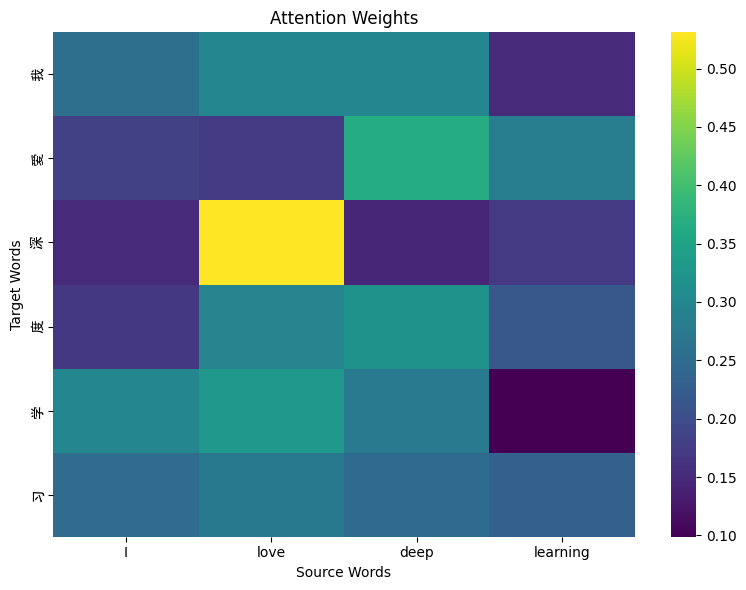

In [ ]:
import subprocess
import platform
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import glob

# Colab/Linux 环境下安装中文字体，macOS/Windows 跳过
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)

# 按优先级查找中文字体文件（兼容 Linux / macOS）
font_path = None
search_patterns = [
    '/usr/share/fonts/**/NotoSansCJK*.ttc',        # Linux (Noto CJK)
    '/usr/share/fonts/**/NotoSansCJK*.otf',         # Linux (Noto CJK otf)
    '/System/Library/Fonts/PingFang.ttc',           # macOS PingFang
    '/System/Library/Fonts/STHeiti*.ttc',            # macOS STHeiti
    '/System/Library/Fonts/Supplemental/Arial Unicode.ttf',  # macOS Arial Unicode
]
for pattern in search_patterns:
    candidates = glob.glob(pattern, recursive=True)
    if candidates:
        font_path = candidates[0]
        break

if font_path:
    print(f"使用字体: {font_path}")
    font_prop = fm.FontProperties(fname=font_path)
else:
    font_prop = None
    print("未找到中文字体，中文可能显示为方块")


def plot_attention(sentence, translation, attention_weights):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(attention_weights, cmap='viridis',
                xticklabels=sentence.split(),
                yticklabels=list(translation), ax=ax)
    # 直接给 Y 轴标签设置字体，绕过 rcParams 字体名解析
    if font_prop:
        for label in ax.get_yticklabels():
            label.set_fontproperties(font_prop)
    plt.xlabel('Source Words')
    plt.ylabel('Target Words')
    plt.title('Attention Weights')
    plt.tight_layout()
    plt.savefig("attention_weights.jpg", dpi=150, bbox_inches="tight")
    plt.show()


# 获取 Attention Map 并绘图
model.eval()
src_text = "I love deep learning"
src_indices = torch.tensor([src_vocab[w] for w in src_text.split()]).unsqueeze(0).to(device)
src_mask = make_pad_mask(src_indices, src_indices, 0)

enc_out = model.encode(src_indices, src_mask)

tgt_indices = torch.tensor([[
    tgt_vocab['<sos>'],
    tgt_vocab['我'], tgt_vocab['爱'],
    tgt_vocab['深'], tgt_vocab['度'],
    tgt_vocab['学'], tgt_vocab['习']
]]).to(device)
tgt_mask = make_subsequent_mask(tgt_indices.size(1)).to(device)

output, attn_weights = model._decoder(model.tgt_embedding(tgt_indices), enc_out, src_mask, tgt_mask)

# 平均所有头的注意力
attn_avg = attn_weights[0].mean(dim=0).detach().cpu().numpy()
plot_attention(src_text, "我爱深度学习", attn_avg[1:])

---
## 结语

恭喜你完成了从零实现 Transformer 的全部内容！

虽然这个模型很小、数据集也很小，但**原理和 ChatGPT、Claude 模型一样**。你把模型放大，数据放大，训练时间变长，就会得到一个非常强大的模型。

### 课后作业

去 Kaggle 或开源数据集下载一些中英、中日或你喜欢的数据集，把模型扩大，看下能不能训练一个自己的翻译模型。